In [3995]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [3996]:
nr_of_seeds = 30 #nr of seeds in the experiments

In [3997]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [3998]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_24040\10849317.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_24040\10849317.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_24040\10849317.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

<Axes: xlabel='method', ylabel='rmse'>

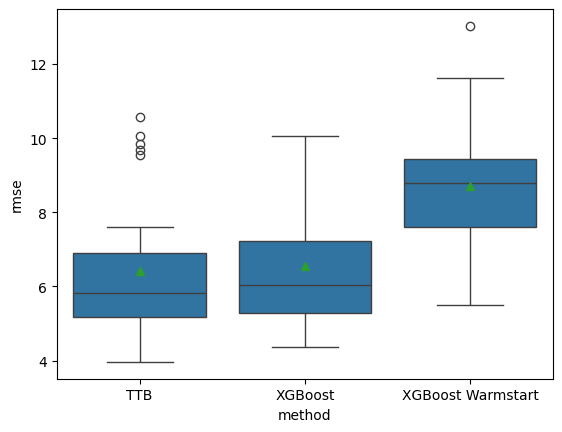

In [3999]:
sub_name = 'volume'

dat = pd.read_csv(f'results_{sub_name}/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results_{sub_name}/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'

# data = pd.read_csv(f'results/xgb_naive.csv')
# naive_xgboost_data = data
# naive_xgboost_data['method'] = 'Naïve XGBoost'

# best_naive_XGBoost, lk = topk_per_d_per_method(
#     naive_xgboost_data,
# ['v', 'target_tree_size'], k=nr_of_seeds
# )
# best_naive_XGBoost['method'] = 'Naïve XGBoost'

data = pd.read_csv(f'results_{sub_name}/xgb_warmstart.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart ['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart , best_XGBoost_params_warmstart  = topk_per_d_per_method(
    xgboost_data_warmstart ,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_warmstart ['method'] = 'XGBoost Warmstart'



df = best_LSTransferTreeBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
df = pd.concat([df, best_XGBoost_warmstart])
#df = pd.concat([df, best_naive_XGBoost])
marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [4000]:
#Obtain best parameters in order based on test rmse
dat = pd.read_csv(f'results_{sub_name}/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=100000
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results_{sub_name}/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=100000
)
best_XGBoost['method'] = 'XGBoost'

data = pd.read_csv(f'results_{sub_name}/xgb_warmstart.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart ['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart , best_XGBoost_params_warmstart  = topk_per_d_per_method(
    xgboost_data_warmstart ,
['v', 'target_tree_size'], k=100000
)
best_XGBoost_warmstart ['method'] = 'XGBoost Warmstart'

# data = pd.read_csv(f'results/two_trada_{index}.csv')
# trada_data = data
# trada_data['method'] = 'two-stage TrAdaBoost.R2'

# best_trada, jk = topk_per_d_per_method(
#     trada_data,
# ['method'], k=nr_of_seeds
# )
# best_trada['method'] = 'two-stage TrAdaBoost.R2'

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_24040\3404690135.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_24040\3404690135.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_24040\3404690135.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

In [4001]:
#Get best params in order
best_LSTransferTreeBoost_params.iloc[::nr_of_seeds]

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,avg_mae,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
1071,0.1,3.0,3.0,0.00,0.1,6.429000,4.514529,30,874.0,400.0,5.267427,3.701382,4.978616,3.682868,TransferTreeBoost
1482,0.1,3.0,3.0,0.05,0.1,6.447705,4.551791,30,880.0,400.0,5.315106,4.067473,5.611101,3.976312,TransferTreeBoost
685,0.1,2.0,1.0,0.05,0.1,6.461520,4.480152,30,869.0,400.0,6.108440,4.508166,4.688109,3.752863,TransferTreeBoost
745,0.1,1.0,3.0,0.00,0.5,6.470404,4.535748,30,870.0,400.0,4.926205,3.782792,7.546844,5.371885,TransferTreeBoost
1098,0.1,3.0,1.0,0.01,0.1,6.470802,4.545903,30,875.0,400.0,6.074231,4.651180,9.706229,5.184820,TransferTreeBoost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1730,0.1,1.0,2.0,0.05,0.1,7.048207,4.781766,30,884.0,400.0,6.011060,4.674019,4.013480,2.909595,TransferTreeBoost
2119,0.1,1.0,3.0,0.01,0.9,7.150802,5.165026,30,889.0,400.0,10.369192,5.874749,6.251377,4.356968,TransferTreeBoost
604,0.1,3.0,1.0,0.01,0.9,7.308441,5.236911,30,868.0,400.0,8.077571,5.896614,5.371562,4.122773,TransferTreeBoost
532,0.1,2.0,1.0,0.01,0.9,7.313327,5.295146,30,867.0,400.0,7.582144,6.205669,7.595027,6.023539,TransferTreeBoost


In [4002]:
#Get best params in order
best_XGBoost_params.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
1,0.1,2.0,6.553302,4.554330,30,1,860.0,4.293956,3.537016,5.999329,4.391917,XGBoost
60,0.1,1.0,6.576646,4.593863,30,60,870.0,5.213666,4.087012,8.002255,5.666685,XGBoost
110,0.1,3.0,6.584339,4.639556,30,110,878.0,5.997142,4.509525,5.307146,4.082430,XGBoost
105,0.1,4.0,6.755353,4.772998,30,105,877.0,10.161128,5.044066,7.083858,5.509444,XGBoost
28,0.1,5.0,6.782300,4.783680,30,28,864.0,6.262653,4.068633,7.426993,5.216498,XGBoost
5,0.1,6.0,6.822837,4.783869,30,5,860.0,5.680650,4.590321,6.945918,5.170343,XGBoost


In [4003]:
#Get best params in order
best_XGBoost_params_warmstart.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
0,0.1,1.0,8.718464,6.270068,30,0,860.0,6.633023,5.143624,9.803573,7.244542,XGBoost Warmstart
61,0.1,2.0,8.966478,6.405482,30,61,870.0,10.763475,7.355314,8.720882,6.767231,XGBoost Warmstart
110,0.1,3.0,10.640758,7.738086,30,110,878.0,8.857167,6.676540,8.374874,6.066991,XGBoost Warmstart
105,0.1,4.0,11.908855,8.443470,30,105,877.0,12.305931,8.107081,15.829143,11.115138,XGBoost Warmstart
28,0.1,5.0,13.699506,9.825799,30,28,864.0,11.774832,8.130321,16.024753,11.867654,XGBoost Warmstart
5,0.1,6.0,14.799842,10.689424,30,5,860.0,10.977532,8.880788,12.007249,9.037619,XGBoost Warmstart


In [4004]:
((best_XGBoost_params.iloc[0]['avg_rmse'] - best_LSTransferTreeBoost_params.iloc[0]['avg_rmse']) / best_XGBoost_params.iloc[0]['avg_rmse'])*100

np.float64(1.896781904015944)

In [4005]:
import numpy as np
np.std(best_XGBoost_params.iloc[:30]['rmse'])

np.float64(1.6645763395486617)